# Proyecto de Generación de Exámenes con LLMs Locales
## Entrega 1 — Diseño, Instalación y Prototipo
**Materia:** Deep Learning  
**Programa:** Ingeniería Mecatrónica  
**Estudiante:** Samuel Felipe Pedreros Chaves 
**Repositorio:** https://github.com/SamuelPCh/GeneradorDeExamenes

## Punto 1. Definición del Caso de Uso

**Caso de uso:** Para este proyecto se eligió desarrollar un generador de exámenes y rúbricas (correspondiente al caso 16, de nivel intermedio).

**Descripción del problema:** Los docentes universitarios o de cualquier institución académica pueden algunas veces invertir mucho tiempo en la creación y redacción de exámenes, preguntas y rúbricas de evaluación para examinar el nivel de conocimiento de sus estudiantes. Esto se convierte rápidamente en un proceso manual y repetitivo, el cual puede presentar errores o inconsistencias entre evaluaciones. Bajo la propuesta de mi docente de Deep Learning, este sistema automatiza el proceso de creación de exámenes usando LLMs locales, permitiendo generar preguntas específicas sobre cualquier tema académico deseado.

**Tipo de tarea:** Generación de texto para exámenes académicos, incluyendo la sección de preguntas, de respuestas y las rúbricas de evaluación.

**Usuarios objetivo:** Profesores universitarios o demás instituciones académicas de cualquier área del conocimiento.

**Justificación:** El uso de los LLMs para generación de contenido educativo es una aplicación directa desarrollada de la materia Deep Learning para automatizar tareas repetitivas. Este modelo o sistema propuesto tiene bastante utilidad y campos de mejora que se han ido descubierto mientras se desarrolla el proyecto. Por ejemplo, el sistema se puede potencializar mediante el ajuste de parámetros como el nivel de dificultad, el número de preguntas, el tipo de pregunta (puede ser abierta, opción múltiple, verdadero/falso) y el área de conocimiento a evaluar. Esta exclusividad dada por el cambio de los parámetros puede ser generada exitosamente por el uso de una base de conocimiento propia del profesor mediante RAG, permitiendo que el modelo cree preguntas basadas en el material específico del curso y con términos o tecnicismos propios de este.

Por otra parte, es importante resaltar los apectos que hacen que este proyecto tenga un beneficio adicional para los docentes y las instituciones, por ejemplo, la privacidad. En el modelo, al ejecutarse completamente de forma local mediante Ollama, ningún dato tendría la necesidad de salir de la institución hacia servidores externos, por lo que se garantizaría la exclusividad de los exámenes generados para cada universidad, eliminando el riesgo de divulgación no deseada de los exámenes y finalmente, protegiendo la propiedad intelectual del material.

## Punto 2. Instalación y Configuración Técnica

### Modelos instalados en Ollama
- **qwen2.5:3b** — 1.9 GB — Modelo principal del proyecto
- **llama3** — 4.7 GB — Modelo alternativo que también se puede implementar
- **qwen2.5** — 4.7 GB — Correspondiente a la versión completa de Qwen

En este punto es importante mencionar que la selección de modelos estuvo condicionada básicamente por las limitaciones de hardware del equipo utilizado (la computadora usada solo cuenta con 8 GB de RAM disponibles), por eso, se priorizaron modelos ligeros como qwen2.5:3b, el cual fue elegido como modelo principal por ser uno de los más eficientes en la relación calidad/peso (pesa únicamente 1.9 GB), y que además, permite ejecutar el modelo sin congelar el sistema. Por otra parte, como se especificó anteriormente, los modelos llama3 y qwen2.5 quedaron disponibles como alternativas para comparaciones, aunque para el dispositivo usado requiereron del cierre de aplicaciones en segundo plano para correr sin problemas.

### Versiones de herramientas
- **Python:** 3.12.9
- **DeepEval:** 3.9.7
- **Ollama:** 0.20.3
- **Opik:** 1.7.3
- **Git:** 2.54.0

### Hardware utilizado
- **RAM:** 8 GB
- **Almacenamiento:** SSD (Windows-SSD)
- **Procesador:** CPU, sin GPU dedicada
- **Sistema Operativo:** Windows

### Repositorio Git
https://github.com/SamuelPCh/GeneradorDeExamenes

### Código "generador.py"

In [2]:
import opik
from opik import track
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"
)

@track
def generar_examen(tema: str, nivel: str = "universitario", num_preguntas: int = 3):
    prompt = f"""Eres un profesor académico universitario. Genera {num_preguntas} preguntas de examen sobre "{tema}" 
    para nivel {nivel}. Para cada pregunta incluye:
    1. La pregunta
    2. La respuesta correcta
    3. La rúbrica de evaluación (2-3 líneas)
    
    Responde en español."""
    
    response = client.chat.completions.create(
        model="qwen2.5:3b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7
    )
    
    return response.choices[0].message.content

if __name__ == "__main__":
    pruebas = [
        ("Integrales definidas", "universitario"),
        ("Circuitos eléctricos en serie", "universitario"),
        ("Programación orientada a objetos", "universitario")
    ]
    
    for tema, nivel in pruebas:
        print(f"\n Generando examen sobre: {tema}")
        resultado = generar_examen(tema=tema, nivel=nivel)
        print(resultado)
        print("-" * 50)


 Generando examen sobre: Integrales definidas
Claro, aquí tienes tres preguntas para un examen sobre "Integrales definidas" con sus respectivas respuestas y rubricas de evaluación:

### Pregunta 1:
**Pregunta:**
Calcular la integral definida \(\int_{1}^{4} (2x + 3) dx\).

**Respuesta Correcta:**
\[ [x^2 + 3x]_1^4 = ((4)^2 + 3(4)) - ((1)^2 + 3(1)) = 20 - 4 = 16 \]

**Rubric de Evaluación:**
La respuesta correcta requiere que se evalúen las operaciones correctamente. La fórmula para calcular la integral definida debe ser aplicada adecuadamente, y los cálculos deben estar bien ordenados.

### Pregunta 2:
Determine el valor de \(k\) en la integral definida \(\int_{0}^{π/2} (x^2 + k) dx = 4\).

**Respuesta Correcta:**
\[ [x^3 / 3 + kx]_0^{π/2} = (\frac{(π/2)^3}{3} + k(π/2)) - (0) \]
\[ \frac{(\pi^3)}{24} + \frac{k\pi}{2} = 4 \]
\[ k = \frac{12 - \frac{\pi^3}{12}}{\pi / 2} = \frac{24 - \pi^3}{6} \]

**Rubric de Evaluación:**
La evaluación debe considerar si la respuesta utiliza correctament

## 3. Evidencias (Pantallazos) de Opik

### Pantallazo 1 — Vista general del proyecto
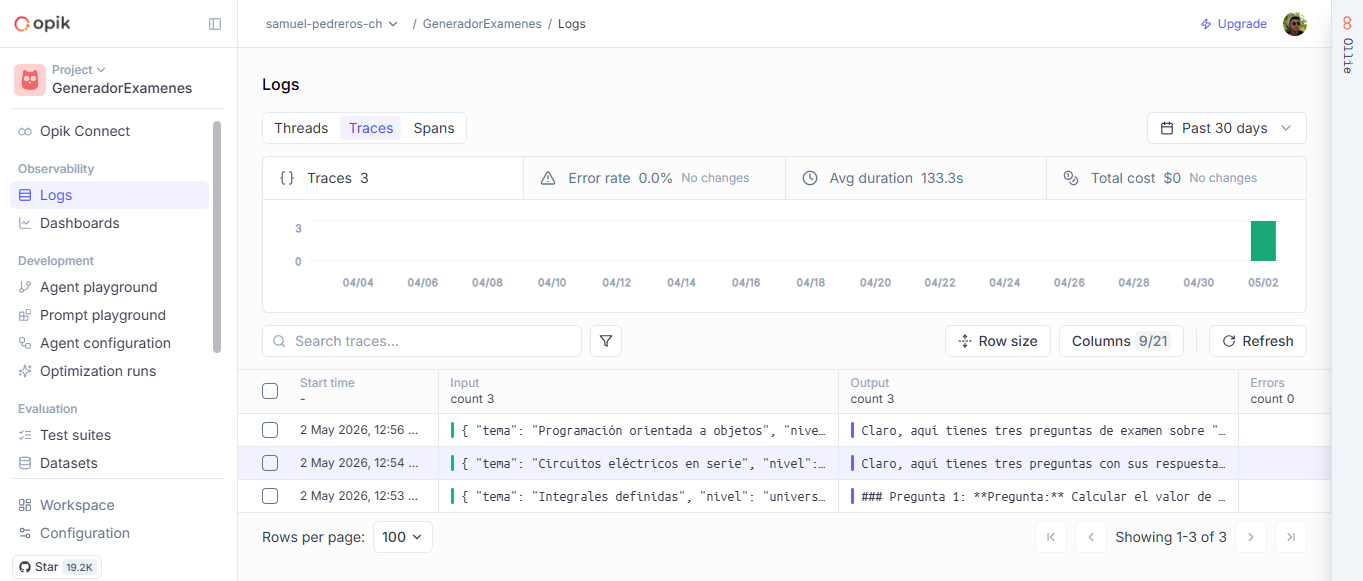

Para la evidencia del dashboard de Opik se optó por mostrar únicamente 3 de las trazas registradas en el proyecto GeneradorExamenes desde su ceración, ejecutadas el 2 de mayo de 2026 antes de la entrega del avance del proyecto con la finalidad de exponer su buen comportamiento. Allí se observa que la tasa de error es 0.0%, por lo que todas las consultas se procesaron exitosamente, además, la duración promedio es de 133.3 segundos, este es el tiempo que tarda el modelo qwen2.5:3b en generar un examen completo con 3 preguntas, respuestas y rúbricas.

### Pantallazo 2 — Detalle de la traza específica ("Integrales definidas")
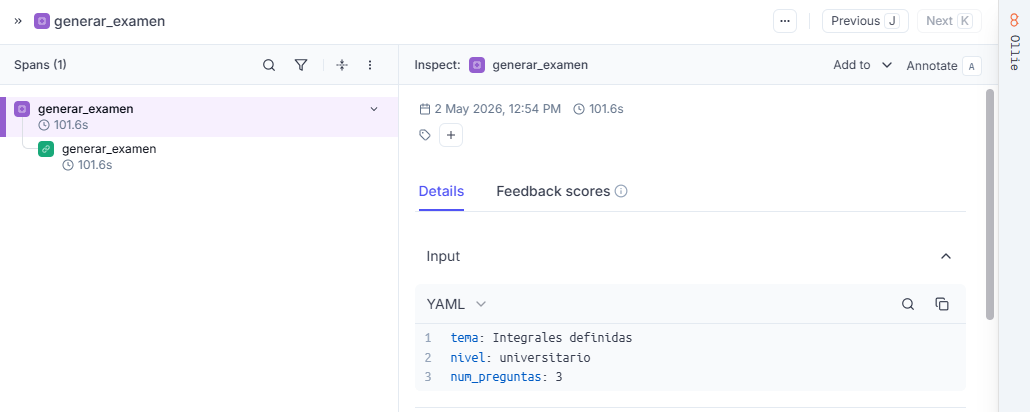
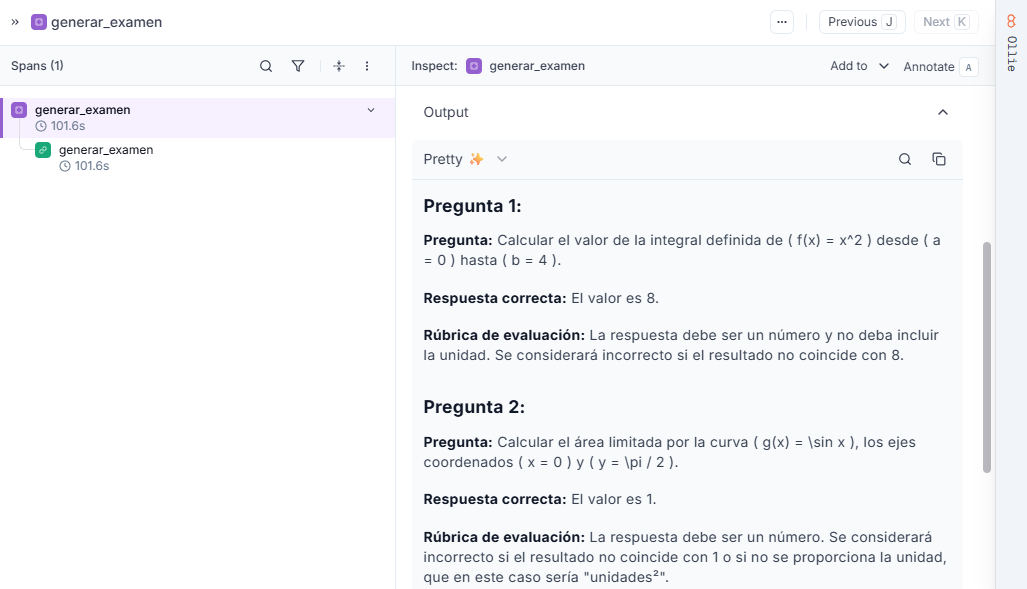
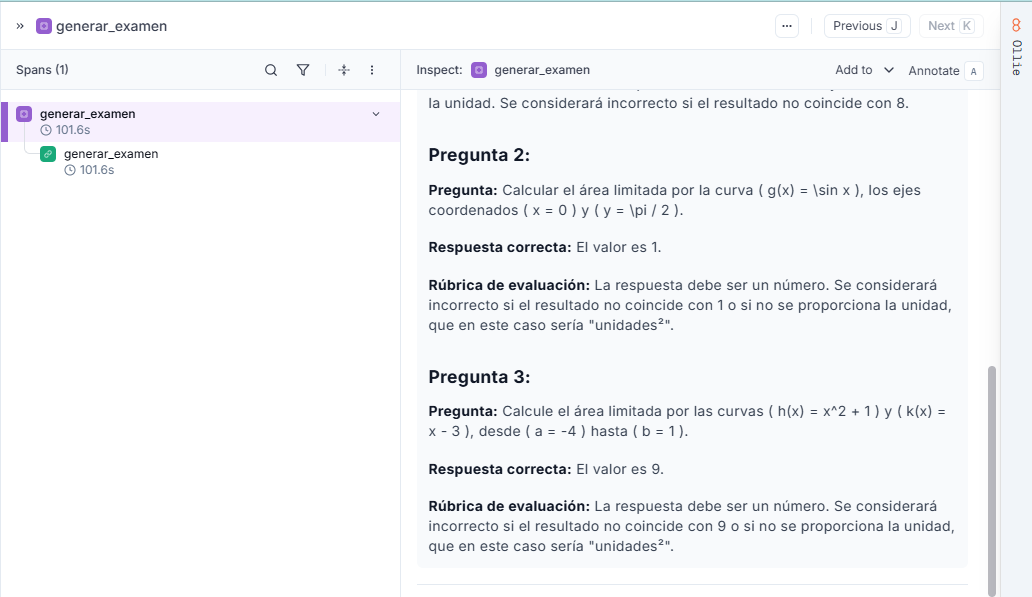

El detalle de la traza seleccionada muestra que Opik registró correctamente el input de la función `generar_examen` con los parámetros esperados (tema "Integrales definidas", nivel "universitario" y num_preguntas 3). Allí también se evidencia que la duración total de esta traza fue de 101.6 segundos, un poco menos del promedio del modelo completo, y lo cual también es esperado ya que que el modelo qwen2.5:3b estaba corriendo completamente en CPU sin GPU dedicada.

Con respecto al "Output de la traza", se evidencia que Opik registró el output completo generado por el modelo, mostrando las 3 preguntas del tema inicial, con sus respectivas respuestas y las rúbricas de calificación. Esta es una de las etapas o partes más importantes del modelo ya que permiten la confirmación de lo que generó el modelo ante una consulta específica en caso de que se detecten respuestas incorrectas en futuras evaluaciones con DeepEval.

### Pantallazo 3 — Estadísticas del proyecto
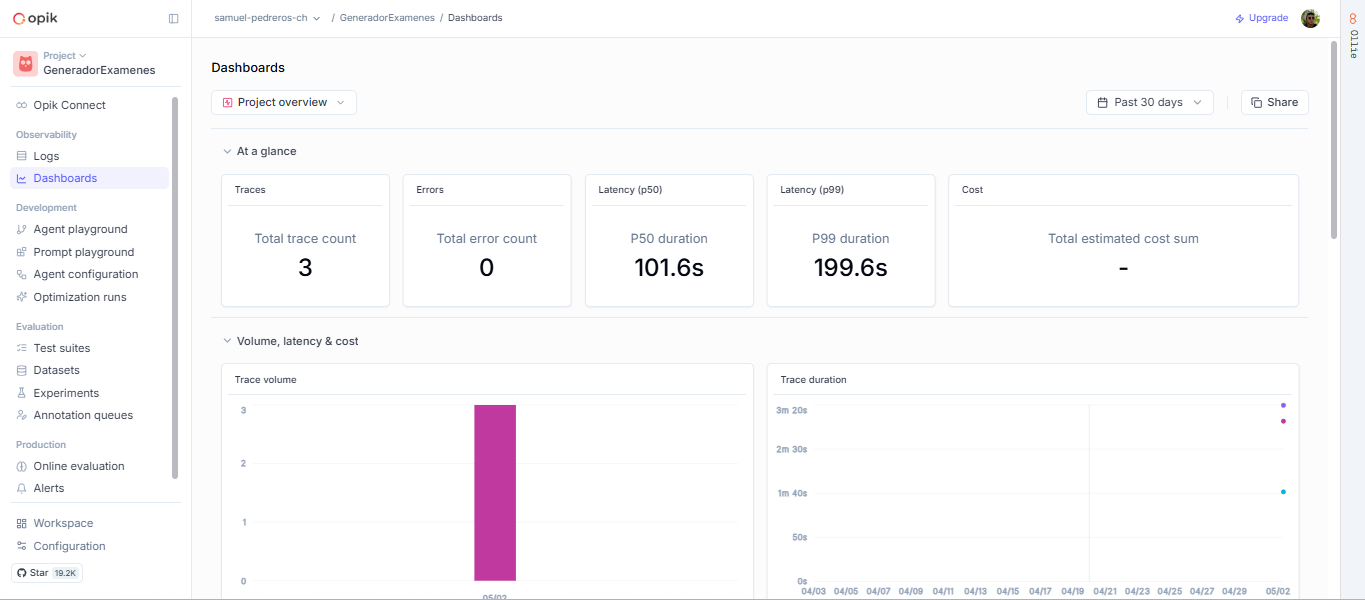

Finalmente, el dashboard de Opik muestra un resumen histórico completo del proyecto, allí se observan las únicas 3 trazas seleccionadas, 0 errores, una latencia P50 de 101.6 segundos (en otras palabras, que el 50% de las consultas tardaron 101.6 segundos o menos en responder) y P99 de 199.6 segundos (es decir, el 99% de las consultas tardaron menos de 199.6 segundos en responder). Estos tiempos de latencia son veraces con respecto al tiempo señalado anteriormente cuando corre en CPU.

## 4. Test en DeepEval

In [11]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pytest", "test_basico.py", "-v", "--tb=short"],
    capture_output=True,
    text=True
)
print(result.stdout)
print(result.stderr)

============================= test session starts =============================
platform win32 -- Python 3.12.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\samue\Documents\DeepEval\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\samue\Documents\DeepEval
plugins: anyio-4.13.0, deepeval-3.9.7, opik-2.0.20, asyncio-1.3.0, repeat-0.9.4, rerunfailures-16.1, xdist-3.8.0
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... collected 4 items

test_basico.py::test_relevancia PASSED                                   [ 25%]
test_basico.py::test_alucinacion PASSED                                  [ 50%]
test_basico.py::test_alucinacion_falsa_esperada PASSED                   [ 75%]
test_basico.py::test_geval_personalizado PASSED                          [100%]Running teardown with pytest sessionfinish...


============================== warnings summary ===============================
test_basico.py:

Durante el desarrollo del test, se intentó ejecutar DeepEval directamente dentro del notebook usando `assert_test`, pero, debido a que el modelo `qwen2.5:3b` es pequeño, este presentó ciertas dificultades para generar un JSON estructurado válido con el formato que DeepEval requiere para procesar las estadísticas de cada métrica. 

Para solucionarlo, se optó por ejecutar los tests mediante `subprocess` apuntando al mismo entorno virtual (este proceso ya se había probado mediante la consola CMD), lo cual permitió correr DeepEval correctamente usando `pytest`, manteniendo todas las métricas requeridas.

Como se pudo observar en la casilla anterior, los 4 tests ejecutados pasaron exitosamente en 346 segundos usando `qwen2.5:3b` como modelo juez.

| Test | Métrica | Resultado |
|------|---------|-----------|
| test_relevancia | AnswerRelevancyMetric | PASSED (25%) |
| test_alucinacion | HallucinationMetric | PASSED (50%) |
| test_alucinacion_falsa_esperada | HallucinationMetric | PASSED (75%) |
| test_geval_personalizado | GEval | PASSED (100%) |

Finalmente, en la tabla anterior se detallaron las métricas evaluadas, en donde, el sistema evaluó correctamente relevancia de respuestas, detección de alucinaciones y calidad del contenido. La duración de 346 segundos (casi 5 minutos) refleja el costo computacional de correr el modelo completamente en CPU. Es importante aclarar que el warning arrojado de `DeprecationWarning` sobre el event loop corresponde a un proceso interno de DeepEval y no afecta el funcionamiento del sistema.

## 5. Diagrama de Arquitectura

El sistema sigue la siguiente arquitectura:

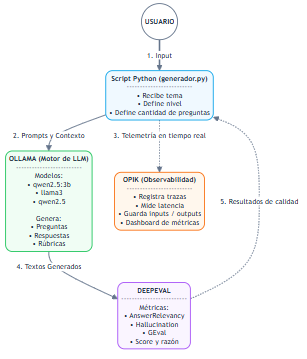

Como se puede observar, el sistema propuesto sigue un flujo retroalimentado que consta de 5 etapas.

1. El usuario envía un input al script Python (detallando el tema, nivel y número de preguntas).
2. El script envía el prompt a Ollama, el cual usa el modelo qwen2.5:3b para generar el examen con preguntas, respuestas y rúbricas, mientras que se registra el comportamiento en tiempo real en Opik.
3. En Opik se registra cada traza con sus inputs y outputs, junto con la latencia y métricas del proyecto.
4. Los textos generados por Ollama como respuesta son enviados a DeepEval para su evaluación.
5. DeepEval aplica las métricas de evaluación `AnswerRelevancyMetric` para verificar que la respuesta sea pertinente a la pregunta, `HallucinationMetric` para detectar información inventada fuera del contexto, y `GEval` para evaluar la calidad del contenido. Aquí, cada métrica devuelve un score numérico entre 0 y 1, y una razón explicando el resultado, valores con los cuales se retroalimenta el script, permitiendo validar y mejorar la calidad de los exámenes generados.


## 6. Plan de Trabajo para el corte 2

| Semana | Actividad |
|--------|-----------|
| 1 | Implementar pipeline RAG con corpus de temas académicos |
| 2 | Integrar vector store (Chroma o FAISS) con embeddings locales |
| 3 | Desarrollar agente "Generador" y agente "Revisor de calidad pedagógica" con CrewAI |
| 4 | Implementar interfaz de usuario con Streamlit |
| 5 | Diseñar experimento formal con 8-15 casos de prueba |
| 6 | Evaluación comparativa entre qwen2.5:3b y llama3 con DeepEval |
| 7 | Análisis crítico de resultados, video demo y manual de uso |